**Introduction**

The project concerns the serious symptoms of heart disease.
i analyzed data, built two machine learning models, and compared them. The project demonstrates how machine learning can make decisions in the healthcare field through predictions

In [359]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib.ticker import StrMethodFormatter
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix



print("Libary secsefully")

Libary secsefully


In [360]:
# load the file 
df=pd.read_csv("heart_disease_risk_dataset_earlymed.csv")

#display the shape of the dataset 
print("dataset shape: ",df.shape)

#display colum name and datatypes
print("\ncolum types: ")
print(df.dtypes)

df.sample(5)

dataset shape:  (70000, 19)

colum types: 
Chest_Pain             float64
Shortness_of_Breath    float64
Fatigue                float64
Palpitations           float64
Dizziness              float64
Swelling               float64
Pain_Arms_Jaw_Back     float64
Cold_Sweats_Nausea     float64
High_BP                float64
High_Cholesterol       float64
Diabetes               float64
Smoking                float64
Obesity                float64
Sedentary_Lifestyle    float64
Family_History         float64
Chronic_Stress         float64
Gender                 float64
Age                    float64
Heart_Risk             float64
dtype: object


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
26659,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,74.0,1.0
29329,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,28.0,0.0
43513,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,79.0,1.0
36465,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,60.0,1.0
23562,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,46.0,1.0


In [361]:
df=df.astype(int)
df.head()

#تحول القيم من فلوت الى انتجر لان القيم لاتحتاج انها تكون فلوت 




,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,48,0
1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,46,0
2,1,0,0,1,0,0,0,0,1,1,0,1,1,1,0,0,1,66,0
3,1,1,0,1,0,0,1,1,1,0,1,1,0,1,1,1,1,60,1
4,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,69,0


In [362]:
print("colum types: ")
print(df.dtypes)
#التأكد من تحويل جميع القيم الى انتجر

colum types: 
Chest_Pain             int64
Shortness_of_Breath    int64
Fatigue                int64
Palpitations           int64
Dizziness              int64
Swelling               int64
Pain_Arms_Jaw_Back     int64
Cold_Sweats_Nausea     int64
High_BP                int64
High_Cholesterol       int64
Diabetes               int64
Smoking                int64
Obesity                int64
Sedentary_Lifestyle    int64
Family_History         int64
Chronic_Stress         int64
Gender                 int64
Age                    int64
Heart_Risk             int64
dtype: object


In [363]:
# التاكد اذا كان فيه بيانات مفقودة او لا
print(df.isnull().sum())
# لايوجد بيانات مفقودة جميع البيانات موجودة 

Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64


In [364]:
print(df.columns)
#التعرف على الكولم وقرائتها وفهمها بشكل صحيح

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='str')


In [365]:
#التأكد من اذا كان فيه تكرار اول لا 
df.duplicated().sum()
#تم العثور على عناصر متكررة وراح يتم ازالتها 

np.int64(6245)

In [366]:
df=df.drop_duplicates()
#طبعا هنا استخدمت دالة دروب عشان تشيل الاعمدة المتكررة

In [367]:
print("dataset shape: ",df.shape)
#هنا شفت الكولم بعد ما شلت الاعمدة المتكررة ونقص عددها

dataset shape:  (63755, 19)


In [368]:
#print(df.describe())
df.describe().T
#هنا ابدااشوف احصائية عن كل عامود 


,count,mean,std,min,25%,50%,75%,max
Chest_Pain,63755.0,0.493891,0.499967,0.0,0.0,0.0,1.0,1.0
Shortness_of_Breath,63755.0,0.495145,0.499980,0.0,0.0,0.0,1.0,1.0
Fatigue,63755.0,0.493514,0.499962,0.0,0.0,0.0,1.0,1.0
Palpitations,63755.0,0.493499,0.499962,0.0,0.0,0.0,1.0,1.0
Dizziness,63755.0,0.496839,0.499994,0.0,0.0,0.0,1.0,1.0
Swelling,63755.0,0.493702,0.499964,0.0,0.0,0.0,1.0,1.0
Pain_Arms_Jaw_Back,63755.0,0.496636,0.499993,0.0,0.0,0.0,1.0,1.0
Cold_Sweats_Nausea,63755.0,0.497608,0.499998,0.0,0.0,0.0,1.0,1.0
High_BP,63755.0,0.494502,0.499974,0.0,0.0,0.0,1.0,1.0
High_Cholesterol,63755.0,0.495443,0.499983,0.0,0.0,0.0,1.0,1.0


In [369]:
df["Heart_Risk"].value_counts()
# طبعا هنا اشوف عدد كل شخص في الكلاسات 

# 0 No Heart Risk
# 1 Heart Risk

Heart_Risk
0    32268
1    31487
Name: count, dtype: int64

In [370]:
# هنا راح اسوي فيتشر جديد  تحسب عدد الاعراض لكل شخص 
symptom=['Chest_Pain','Shortness_of_Breath','Fatigue','Palpitations','Dizziness','Swelling','Pain_Arms_Jaw_Back','Cold_Sweats_Nausea']
df['symptom']=df[symptom].sum(axis=1)
print('columns after add symptom ',df.shape)
df.head()
#هنا تأكدت ان الفيتشر انضافت 

columns after add symptom  (63755, 20)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk,symptom
0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,48,0,1
1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,46,0,2
2,1,0,0,1,0,0,0,0,1,1,0,1,1,1,0,0,1,66,0,2
3,1,1,0,1,0,0,1,1,1,0,1,1,0,1,1,1,1,60,1,5
4,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,69,0,2


In [371]:
#هنا راح اسوي فيتشر تحسب عدد الاعراض اللي تكون مرتبطة بمرض القلب 
risk_symptom=['Chest_Pain','Shortness_of_Breath','Pain_Arms_Jaw_Back','Cold_Sweats_Nausea','Dizziness']
df['risk_symptom']=df[risk_symptom].sum(axis=1)
print ('columns after add risk symptom',df.shape)
df.head()



columns after add risk symptom (63755, 21)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,...,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk,symptom,risk_symptom
0,0,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,48,0,1,0
1,0,1,0,1,0,0,0,0,1,0,...,1,1,0,0,0,0,46,0,2,1
2,1,0,0,1,0,0,0,0,1,1,...,1,1,1,0,0,1,66,0,2,1
3,1,1,0,1,0,0,1,1,1,0,...,1,0,1,1,1,1,60,1,5,4
4,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,69,0,2,1


In [372]:
# هنا راح اسوي فيتشر جديدة تتكلم عن اسلوب حياة الشخص اذا كان اسلوب حياته غير صحي
lifestyle=['Smoking','Obesity','Sedentary_Lifestyle','Chronic_Stress']
df['lifestyle']=df[lifestyle].sum(axis=1)
print('columns after add featrue ',df.shape)
df.head()

columns after add featrue  (63755, 22)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,...,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk,symptom,risk_symptom,lifestyle
0,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,48,0,1,0,2
1,0,1,0,1,0,0,0,0,1,0,...,1,0,0,0,0,46,0,2,1,2
2,1,0,0,1,0,0,0,0,1,1,...,1,1,0,0,1,66,0,2,1,3
3,1,1,0,1,0,0,1,1,1,0,...,0,1,1,1,1,60,1,5,4,3
4,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,69,0,2,1,0


In [373]:
#هنا اشيك اذا كان فيه اوتلايرز او لا بما انه اغلب القيم 0,1 فا راح اشوف العمر اذا كان فيه اوتلايرز او لا
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR= Q3-Q1

lower_quatile_Q1= Q1 - 1.5*IQR 
upper_quatile_Q3= Q3 + 1.5*IQR 
outliers=df[(df['Age']<lower_quatile_Q1)|(df['Age']>upper_quatile_Q3)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_quatile_Q1)
print("Upper Bound:", upper_quatile_Q3)
print("Number of outliers:", len(outliers))
#هنا تبين معي انه مافيه اوتلايرز في العمر 

Q1: 44.0
Q3: 66.0
IQR: 22.0
Lower Bound: 11.0
Upper Bound: 99.0
Number of outliers: 0


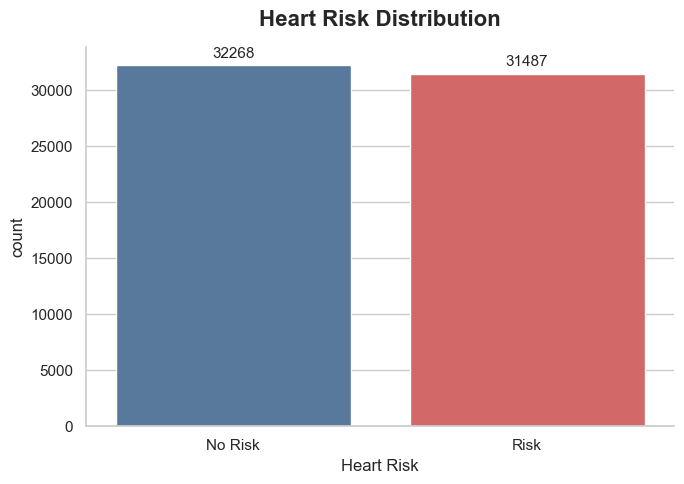

In [374]:
#هنا بديت احط الستايل حق الرسمة 
sns.set_theme(style="whitegrid")# يخلي خلفية الرسمة بيضا وفيها خطوط فيفة (whitegrid) السطر هذا يخلي الرسمة افضل و خيار 
plt.figure(figsize=(7,5)) # هنا نحدد حجم الرسمة 
ax=sns.countplot(data=df,x='Heart_Risk',hue='Heart_Risk',
palette={0: "#4C78A8", 1: "#E45756"},legend=False)
#لانه يحسب القيم في الكولم(countplot) هنا استخدمت
#عشان يخلي كل عامود في الرسمة له لون(hue) هنا استخدمت
#عشان اغير الوان الاعمدة ويكون كل عامود له لون(palette) بعدها استخدمت 
#وهنا استعملت لانه يخفي مربع الشرح اللي يجي بالجنب لان ما يحتاج وكمان لاني حطيت الاسامي بالجنب 


# هنا بديت اكتب العنوان و عنوان الاكس و الواي 
plt.title('Heart Risk Distribution',fontsize=16,fontweight='bold',pad=15)
plt.xlabel('Heart Risk',fontsize=12)
plt.ylabel('count',fontsize=12)
# هنا حطيت التايتل في البداية و بعدها حجم الخط و الخط يكون عريض و الاخيرة تخلي في مسافة بين العنوان والرسمة تحت
ax.set_xticks([0,1])
ax.set_xticklabels(['No Risk','Risk'],fontsize=11)
#هنا حطيت الاسامي تحت عند الاكس في البداية حطيت 0,1 عشان عندنا بس القيمتين هذي وبعده بالامر غيرت اسماء القيم الى الاسماء اللي ابغاها 
for container in ax.containers:
    ax.bar_label(container,fontsize=11,padding=3)

sns.despine()
plt.tight_layout()
plt.show()




**insight**
This shows us that people at high risk of heart disease and people have no risk are very similar.

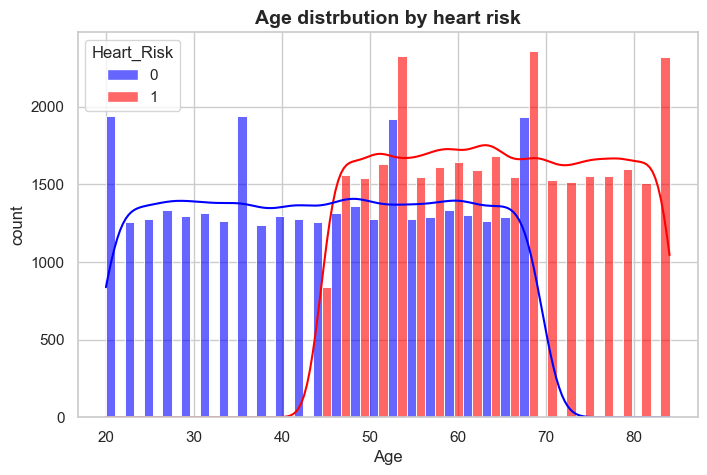

In [375]:
#هنا بسوي رسمة تقارن بين الناس اللي عندهم امراض قلب و اللي ماعندهم عن طريق العمر 

plt.figure(figsize=(8,5))
sns.histplot(data=df ,x='Age',hue='Heart_Risk',bins=30,kde=True,multiple='dodge',
palette={0:'blue', 1:'red'},alpha=0.6)
plt.title('Age distrbution by heart risk',fontsize=14,fontweight='bold')
plt.xlabel('Age')
plt.ylabel('count')
plt.show()










    
    #hue= هنا استخدمت الدالة هذي عشان يثسم بيانات خطر الاصابة 
    #bins=30 هذي الامر يخليي فيه تقسيمات في العمر يخليها في مجموعات لان الداتا كبيرة 

    #kde=True هذا لامر يضيف لي خط في الرسمة 
    #multiple='dodge' هذا الامر يخلي الاعمدة تكون جنب بعض عادي وماتكون متداخة 
   # alpha=0.7 الامر هذا يتحكم في ان اللون يكون شفاف وكل ما كان اكثر صار اغمق 


**insight**
This shows us that the people most susceptible to heart disease are the elderly, and that age is an important factor in developing heart disease.

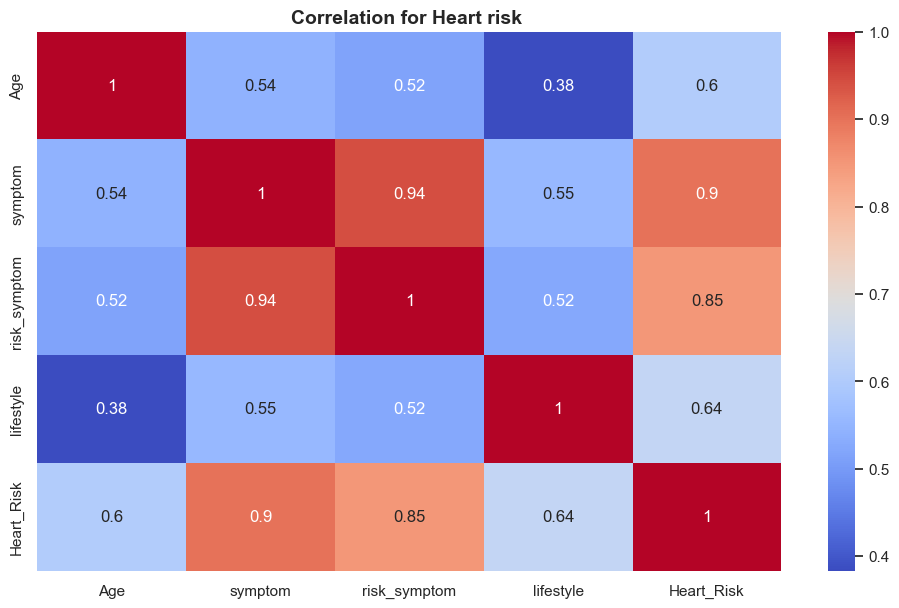

In [376]:
plt.figure(figsize=(12,7))
sns.heatmap(df[['Age','symptom','risk_symptom','lifestyle','Heart_Risk']].corr(),
            annot= True, cmap='coolwarm')
plt.title('Correlation for Heart risk ', fontsize=14,fontweight='bold')
plt.show()



**insight** The correlation heatmap shows that symptom has the strongest relationship with Heart risk  The correlation between symptom and Heart risk and risk symptom also has strong relationship with Heat risk and age has relationships  with Heart risk


In [377]:
X=df.drop('Heart_Risk',axis=1)
y=df['Heart_Risk']
#هنا شلت الهارت ريسك لانه هو اللي راح يتوقعه النموذج 
# متغير اكس  هو اللي راح يتعلم منه بدون عامور الهارت ريسك
# و متغير واي هو اللي يحاول يتوقعه 

In [378]:
#هنا بدبت اقسم البيانات بين تدريب واختبار
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#stratify=y هنا استعملت عشان يسوي توازن في التدريب و الاختبار
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

pca=PCA(n_components=0.95)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)
ratios = pca.explained_variance_ratio_
print(f'total explained {ratios.sum():.4f}')
print('before pca',X_train_scaled.shape)
print('after pca',X_train_pca.shape)
#هنا طبعت النتيجة قبل وبعد 



total explained 0.9692
before pca (51004, 21)
after pca (51004, 17)


In [379]:
logistic_model=LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_pca,y_train)
y_pred_logistic=logistic_model.predict(X_test_pca)
# هنا سويت مودل لوجيستك لان الداتا 0و 1 ويعتبر مودل سريع ويعطي اكيورسي عالي 

print(f'Accuracy: {accuracy_score(y_test,y_pred_logistic):.4f}')
print(f'precision:{precision_score(y_test,y_pred_logistic):.4f} ')
print(f'recall: {recall_score(y_test,y_pred_logistic):.4f}')
print(f'f1 score: {f1_score(y_test,y_pred_logistic):.4f}')


Accuracy: 0.9910
precision:0.9905 
recall: 0.9913
f1 score: 0.9909


In [380]:
rf_model=RandomForestClassifier(n_estimators=100,max_depth=8,min_samples_split=20,min_samples_leaf=10,max_features="sqrt",random_state=42,n_jobs=1)
rf_model.fit(X_train_pca,y_train)
y_pred_rf=rf_model.predict(X_test_pca)
#هنا اخترت الراندون فورسيت لان البايانات كثير والراندوم فروسيت افضل من الديسجون تري لانها تسوي اكثر من شجرة عكس الديسجون اللي تكون شجرة وحدة
print(f'Accuracy: {accuracy_score(y_test,y_pred_rf):.4f}')
print(f'precision:{precision_score(y_test,y_pred_rf):.4f} ')
print(f'recall: {recall_score(y_test,y_pred_rf):.4f}')
print(f'f1 score: {f1_score(y_test,y_pred_rf):.4f}')

Accuracy: 0.9899
precision:0.9897 
recall: 0.9898
f1 score: 0.9898


In [381]:
#هنا راح اسوي مقارنة بين كل مودل وقت التدريب و الاختبار 
#راح اخذ اعلى اكيورسي لكل مودل ونقارن بينهم 
train_x_log=logistic_model.predict(X_train_pca)
test_x_log=logistic_model.predict(X_test_pca)

train_x_rf=rf_model.predict(X_train_pca)
test_x_rf=rf_model.predict(X_test_pca)


print(f'Recall train in logistic: {recall_score(y_train,train_x_log):.4f}')
print(f'Recall test in logistic: {recall_score(y_test,test_x_log):.4f}')

print(f'accuracy train in random forest: {accuracy_score(y_train,train_x_rf):.4f}')
print(f'accuracy test in random forest: {accuracy_score(y_test,test_x_rf):.4f}')


Recall train in logistic: 0.9904
Recall test in logistic: 0.9913
accuracy train in random forest: 0.9903
accuracy test in random forest: 0.9899


In [382]:
comparision_models=pd.DataFrame({
    'Model':['LogisticRegression','Random Forest'],
    'accuracy':[accuracy_score(y_test,y_pred_logistic),
                accuracy_score(y_test,y_pred_rf)],

    'precision':[precision_score(y_test,y_pred_logistic),
                 precision_score(y_test,y_pred_rf)],
    
    'recall':[recall_score(y_test,y_pred_logistic),
                recall_score(y_test,y_pred_rf)],

    'f1':[f1_score(y_test,y_pred_logistic),
        f1_score(y_test,y_pred_rf)]


    
})
comparision_models
#هنا استعملت الداتا فريم عشان اسوي مقارنة بين المودل 
#طلع معي اللوجستيك اعلى من الراندوم فروسيت بفارق بسيط 
#سبب انه النتايج عالية لانه البيانات باينري وسهل على المودل يتوقعهم 
#افضل نتيجة في اللوجيستك كانت الريكال 
#افضل نتيجة في الراندوم فورست كانت اكيورسي 


,Model,accuracy,precision,recall,f1
0,LogisticRegression,0.990981,0.990479,0.991266,0.990872
1,Random Forest,0.989883,0.989679,0.989836,0.989758


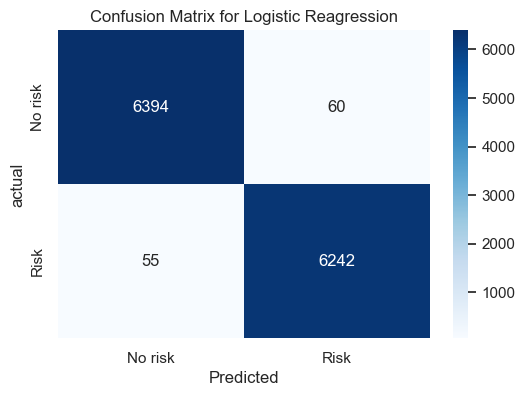

In [383]:
cx_log=confusion_matrix(y_test,y_pred_logistic)

plt.figure(figsize=(6,4))
sns.heatmap(cx_log,annot=True,fmt='d',cmap='Blues',
            xticklabels=['No risk','Risk'],
            yticklabels=['No risk','Risk']
            )

plt.title('Confusion Matrix for Logistic Reagression')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.show()
#هنا سويت الماتريكس عشان اشوف توقعات مودل اللوجيستك 


**insight**
The model had few errors, meaning most of its predictions were correct and the percentage of incorrect predictions was very low.

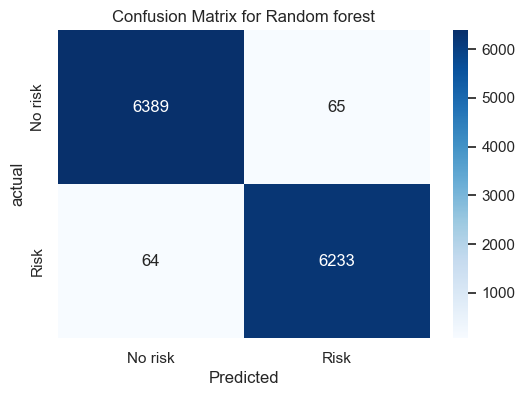

In [384]:
cx_rf=confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cx_rf,annot=True,fmt='d',cmap='Blues',
            xticklabels=['No risk','Risk'],
            yticklabels=['No risk','Risk']
            )

plt.title('Confusion Matrix for Random forest')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.show()
#وهنا سويت الماتركس حقت الفورست 

**insight** Here Random Forest  Model prediction was good, but not the same Logistic Regression although the percentage between them was close.

**insights**

What we learned here is that age plays a role in heart disease, and lifestyle also contributes people with unhealthy lifestyles are more prone to heart disease.

The training and test results were very similar, and there was no overfitting.

The Random Forest  and Logistic Regression model results were high, but the other's were slightly better, which means they are all doing well.

**conclusion**

In this project, I used Bayanri data, which discusses the risk of developing heart disease. Initially, I familiarized myself with the data, created an EDA, and added three new features: one to calculate the number of symptoms per person, another to calculate the severity of heart disease symptoms, and a third to analyze the person's lifestyle and activities that contribute to heart disease. I then removed the heart risk element before creating the model, as its purpose was to predict the likelihood of the person developing the disease. After that, I started the model, selecting Logistic Regression and Random Forest, and created a scale followed by PCA. I implemented these during training, and after testing, Logistic Regression scored slightly higher than Random Forest.Also, the training and testing scores were very close, which shows that there was no clear overfitting or underfitting.